In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Midpoint method

(a) Expand $y(t_n+h)$ about $y(t_n)$ with a Taylor series:
$$y(t_n+h)\approx y(t_n) + h \dot{y}(t_n) + {h^2\over 2} \ddot{y}(t_n) + \mathcal{O}(h^3).$$
Next, use the fact that $y$ depends on $t$ explicitly and implicitly through $y(t)$. The chain rule gives
$$\ddot{y} = \dot{f} = {\partial f\over \partial t} + {\partial f\over\partial y} \dot{y} = {\partial f\over\partial t} + {\partial f\over \partial y} f$$
and therefore
$$y(t_n+h)\approx y(t_n) + h f_n + {h^2\over 2} \left[\left.{\partial f\over\partial t}\right|_n + \left.{\partial f\over \partial y}\right|_n f_n\right] + \mathcal{O}(h^3),$$
where subscript $n$ means evaluated at $t=t_n$, $y=y_n$.

(b) Do a 2D expansion as described in the question:
$$f(t_n+{h\over 2}, y_n + {h\over 2}f_n) \approx f_n + {h\over 2}\left.{\partial f\over\partial t}\right|_n + {h\over 2} f_n \left.{\partial f\over\partial y}\right|_n + \mathcal{O}(h^2).$$
Now multiplying by $h$ we get
$$hf(t_n+{h\over 2}, y_n + {h\over 2}f_n) \approx hf_n + {h^2\over 2}\left[\left.{\partial f\over\partial t}\right|_n + f_n \left.{\partial f\over\partial y}\right|_n\right] + \mathcal{O}(h^3),$$
which is the term on the right hand side that we found in part (a).
We've recreated the midpoint rule, but now with an error estimate:
$$y(t_n+h)\approx y(t_n) + hf(t_n+{h\over 2}, y_n + {h\over 2}f_n) + \mathcal{O}(h^3).$$

This shows that the error in one midpoint step is $\mathcal(h^3)$.

(c) We refer to the midpoint rule as a second order integrator because the global error is second order. If we integrate between fixed endpoints, the number of steps we need is $(t_b-t_a)/h$, so we accumulate the local $h^3$ error by a factor $\propto 1/h$, giving an overall error scaling of $h^2$. (For a concrete example, imagine that you half the step size. The local error goes down by a factor of 8. But we then have to take twice as many steps, which doubles the overall error. The total error only goes down by a factor of 4.) 

## 2: Radioactive decay sequence

In [2]:
# define some alternative time units we can use later
hour = 3600
day = 24* hour
# the half-lives for each element
t_half = (3.6 * day, 55.0, 0.14, 10.6 * hour)
# convert them into individual rates
(r1, r2, r3, r4) = np.log(2.0) / t_half

Labelling the elements from 1 to 5, the set of equations we need to solve is
$${dx_1\over dt} = -r_1 x_1$$
$${dx_2\over dt} = r_1 x_1 -r_2 x_2$$
$${dx_3\over dt} = r_2 x_2 -r_3 x_3$$
$${dx_4\over dt} = r_3 x_3 -r_4 x_4$$
$${dx_5\over dt} = r_4 x_4.$$
We can use our code for the linear system from class. 

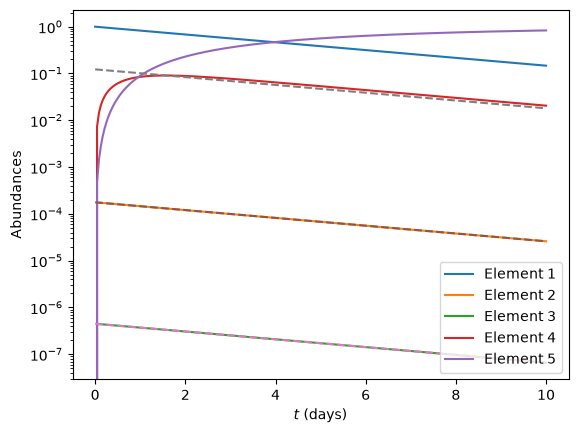

In [3]:
# the matrix of coefficients
C = np.array([ [ r1, 0, 0, 0, 0],
               [ -r1, r2, 0, 0, 0],
               [ 0, -r2, r3, 0, 0],
               [ 0, 0, -r3, r4, 0],
               [ 0, 0, 0, -r4, 0 ] ])

h = 1 * hour
t_end = 10 * day
nsteps = int(t_end/h)

# length nsteps+1 because we also store the initial condition
x = np.zeros((nsteps+1,5))

# Explicit update
A = np.linalg.inv(np.identity(5) + h*C)

# Initial conditions
x[0,0] = 1
x[0,1] = 0
x[0,2] = 0
x[0,3] = 0
x[0,4] = 0

for i in range(1,nsteps+1):
    x[i] = A@x[i-1]
    
t = h * np.arange(nsteps+1) / day

plt.plot(t,x[:,0],label="Element 1")
plt.plot(t,x[:,1],label="Element 2")
plt.plot(t,x[:,2],label="Element 3")
plt.plot(t,x[:,3],label="Element 4")
plt.plot(t,x[:,4],label="Element 5")

plt.yscale('log')
plt.legend()

plt.plot(t,x[:,0] * r1/r2,'--')
plt.plot(t,x[:,0] * r1/r3,'--')
plt.plot(t,x[:,0] * r1/r4,'--')

plt.xlabel(r'$t$ (days)')
plt.ylabel(r'Abundances')

plt.show()

The elements with short half-lives quickly get into an equilibrium with $dx/dt\approx 0$. This is because the evolution timescale is very long (set by the slowest decay rate in the chain) and therefore in an equation such as 
$${dx_2\over dt} = r_1x_1-r_2x_2,$$
the two terms on the right hand side must almost cancel out because they are both much larger than the very slow evolution rate on the left hand side.

This means that we can write for example $x_2\approx x_1 r_1/r_2$. For the next element, $x_3\approx x_2 r_2/r_3\approx x_1 r_1/r_3$. These relations are plotted as dashed lines and do a good job at reproducing the elements with short half lives that get into equilibrium.

## 3. Second order implicit integration

In class, we integrated the finite-amplitude pendulum by solving the equation
$$\mathbf{F}(\mathbf{y}) = \mathbf{y} - \mathbf{y}_n - h \mathbf{f}\left(\mathbf{y}\right) = 0$$ at each timestep. For the second order methods this becomes either
$$\mathbf{F}(\mathbf{y}) = \mathbf{y} - \mathbf{y}_n - h \mathbf{f}\left({\mathbf{y}+\mathbf{y}_n\over 2}\right) = 0$$
for implicit mipoint or
$$\mathbf{F}(\mathbf{y}) = \mathbf{y} - \mathbf{y}_n - {h\over 2} \mathbf{f}\left(\mathbf{y}_n\right) - {h\over 2} \mathbf{f}\left(\mathbf{y}\right) = 0$$
for Crank Nicolson.

For backwards Euler, we had 
$$\mathbf{F}(\mathbf{y}) = \begin{pmatrix} \theta - \theta_n -h\omega \\ \omega - \omega_n + h \sin\theta \end{pmatrix}.$$ 
This becomes
$$\mathbf{F}(\mathbf{y}) = \begin{pmatrix} \theta - \theta_n -{h\over 2}(\omega_n+\omega)\\ \omega - \omega_n + h \sin({\theta_n+\theta\over 2}) \end{pmatrix}.$$ 
for implicit midpoint, and
$$\mathbf{F}(\mathbf{y}) = \begin{pmatrix} \theta - \theta_n -{h\over 2}(\omega_n+\omega) \\ \omega - \omega_n + {h\over 2} \sin\theta_n + {h\over 2} \sin\theta \end{pmatrix}.$$ 
for Crank Nicolson.

The corresponding Jacobian $\mathbf{J} = \partial \mathbf{F}/ \partial
\mathbf{y}$ for backwards Euler was 
$$\mathbf{J}(\mathbf{y}) = \begin{pmatrix} 1 & -h \\ h\cos\theta & 1  \end{pmatrix}.$$
This is now 
$$\mathbf{J}(\mathbf{y}) = \begin{pmatrix} 1 & -{h\over 2} \\ {h\over 2}\cos({\theta_n+\theta\over 2}) & 1  \end{pmatrix}$$
for implicit midpoint, and 
$$\mathbf{J}(\mathbf{y}) = \begin{pmatrix} 1 & -{h\over 2} \\ {h\over 2}\cos\theta & 1  \end{pmatrix}$$
for Crank Nicolson.


In [2]:
def integrate(nsteps, h, integrator):

    # Initial conditions
    theta = np.zeros(nsteps+1)
    omega = np.zeros(nsteps+1)
    
    theta[0] = 0.5*np.pi    # initial angle (radians)
    omega[0] = 0.0
    
    # Newton parameters
    tol = 1e-3
    max_iter = 10
    
    
    for n in range(nsteps):
        
        # Initial guess for theta_{n+1}, omega_{n+1}
        # Use the previous timestep as the initial guess
        x = np.array([theta[n], omega[n]])
    
        # Newton iterations
        for k in range(max_iter):
    
            th, om = x
    
            if integrator == 'euler':
                # Euler
                F = np.array([th - theta[n] - h * om, 
                               om - omega[n] + h * np.sin(th)])
                J = np.array([[1.0,  -h],[h * np.cos(th),  1.0]])
            elif integrator == 'midpoint':       
                # Midpoint
                F = np.array([th - theta[n] - (h/2) * (om+omega[n]), 
                           om - omega[n] + h * np.sin((th+theta[n])/2)])
                J = np.array([[1.0,  -h/2],[(h/2) * np.cos((th+theta[n])/2),  1.0]])
            elif integrator == 'cranknicolson':
                # Crank Nicolson
                F = np.array([th - theta[n] - (h/2) * (om+omega[n]), 
                           om - omega[n] + (h/2) * (np.sin(th)+np.sin(theta[n]))])
                J = np.array([[1.0,  -h/2],[(h/2) * np.cos(th),  1.0]])
    
            # solve for delta y and update
            delta = np.linalg.solve(J, -F)
            x += delta
    
            #print('iteration %d, delta = %lg' % (k, np.linalg.norm(delta)))
            
            # Check convergence
            if np.linalg.norm(delta) < tol:
                break
    
        # Store converged solution
        theta[n+1] = x[0]
        omega[n+1] = x[1]

    return theta, omega

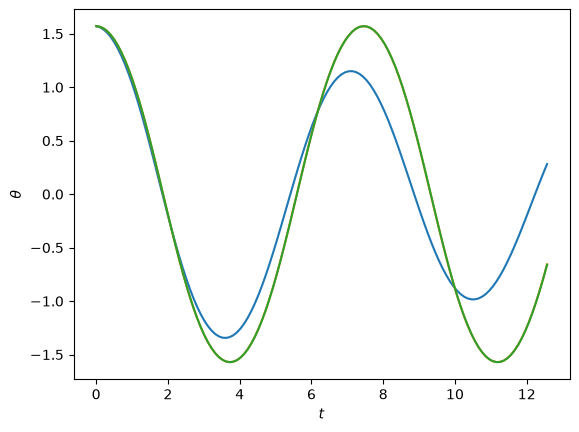

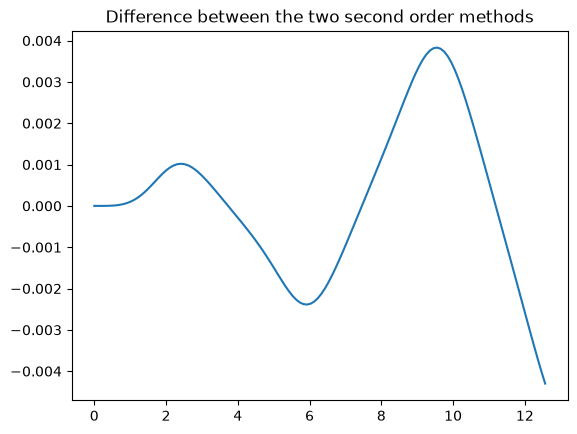

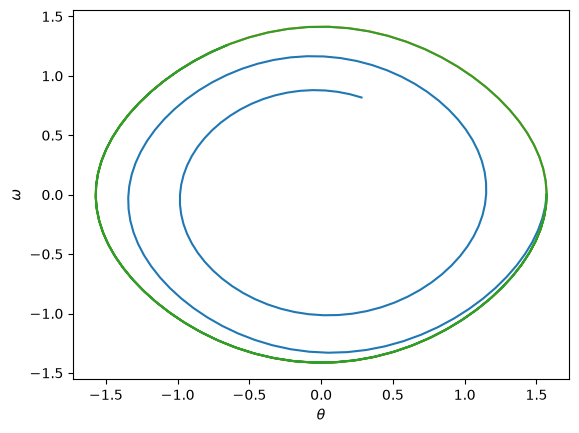

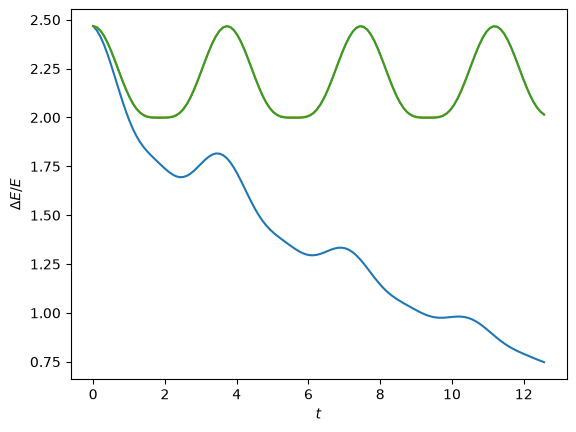

In [8]:
h = 0.1
t_end = 2*np.pi * 2
nsteps = int(t_end / h)

theta, omega = integrate(nsteps, h, 'euler')
theta2, omega2 = integrate(nsteps, h, 'midpoint')
theta3, omega3 = integrate(nsteps, h, 'cranknicolson')

# Plot
t = np.linspace(0, t_end, nsteps+1)

plt.plot(t, theta)
plt.plot(t, theta2)
plt.plot(t, theta3)

plt.xlabel(r'$t$')
plt.ylabel(r'$\theta$')
plt.show()

plt.figure()
plt.plot(t,theta3-theta2)
plt.title('Difference between the two second order methods')
plt.show()

plt.figure()
plt.plot(theta,omega)
plt.plot(theta2,omega2)
plt.plot(theta3,omega3)
plt.ylabel(r'$\omega$')
plt.xlabel(r'$\theta$')
plt.show()

plt.figure()
E = theta**2 + omega**2
E2 = theta2**2 + omega2**2
E3 = theta3**2 + omega3**2

plt.plot(t, E)
plt.plot(t, E2)
plt.plot(t, E3)

#plt.plot(t, (E-E[0])/E[0])
#plt.plot(t, (E2-E2[0])/E2[0])
#plt.plot(t, (E3-E3[0])/E3[0])
plt.ylabel(r'$\Delta E/E$')
plt.xlabel(r'$t$')
plt.show()

Now we can check the scaling with $N$. As a reference value, we can take the final energy from the highest resolution simulation as the "truth" and compare the lower resolution simulations with that.

Text(0, 0.5, '$\\Delta E/E$')

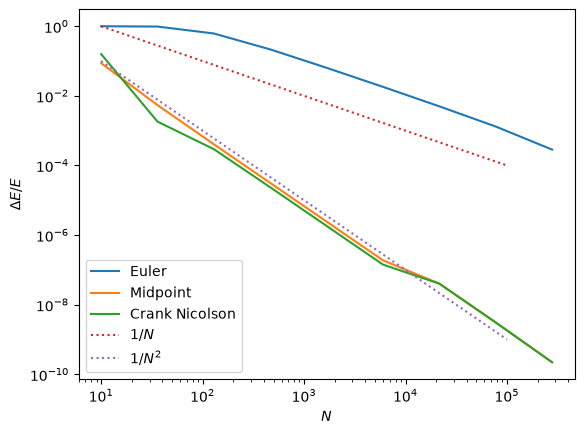

In [13]:
n_vec = np.linspace(1,6,10)
E_vec = np.zeros_like(n_vec)
E2_vec = np.zeros_like(n_vec)
E3_vec = np.zeros_like(n_vec)

for i, n in enumerate(n_vec):
    nsteps = int(10**n)
    t_end = 2*np.pi * 2
    h = t_end / nsteps

    theta, omega = integrate(nsteps, h, 'euler')
    E_vec[i] = theta[-1]**2 + omega[-1]**2
    theta, omega = integrate(nsteps, h, 'midpoint')
    E2_vec[i] = theta[-1]**2 + omega[-1]**2
    theta, omega = integrate(nsteps, h, 'cranknicolson')
    E3_vec[i] = theta[-1]**2 + omega[-1]**2

err = np.abs(E_vec[-1] - E_vec)/E_vec[-1]
err2 = np.abs(E2_vec[-1] - E2_vec)/E2_vec[-1]
err3 = np.abs(E3_vec[-1] - E3_vec)/E3_vec[-1]

plt.plot(10**n_vec[:-1], err[:-1],label='Euler')
plt.plot(10**n_vec[:-1], err2[:-1],label='Midpoint')
plt.plot(10**n_vec[:-1], err3[:-1],label='Crank Nicolson')

plt.plot((10,1e5),(1.0,1e-4),':',label=r'$1/N$')
plt.plot((10,1e5),(1e-1,1e-9),':',label=r'$1/N^2$')

plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$N$')
plt.ylabel(r'$\Delta E/E$')
    